In [1]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import lidar_processor, era5_processor, plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

In [2]:
"""Interpolate ERA5 data to regular grid"""
file_T21 = "../data/eulag/era5_ml_T21.nc"
file_T21_int = "../data/eulag/era5_ml_T21_int.nc"
# era5_processor.prepare_T21(file_T21, file_T21_int)

: 

In [3]:
ds = xr.open_dataset("../data/eulag/era5_ml_T21_int.nc")
# ds = xr.open_dataset("../data/coral/era5-region/20180618-1644-ml-int.nc")

ds = ds.sel(latitude=slice(-48,-52), longitude=slice(278,282))
ds

<xarray.Dataset>
Dimensions:    (time: 72, level: 201, latitude: 17, longitude: 17)
Coordinates:
  * time       (time) datetime64[ns] 2018-06-16 ... 2018-06-18T23:00:00
  * latitude   (latitude) float32 -48.0 -48.25 -48.5 ... -51.5 -51.75 -52.0
  * longitude  (longitude) float32 278.0 278.2 278.5 278.8 ... 281.5 281.8 282.0
  * level      (level) float64 0.0 400.0 800.0 ... 7.92e+04 7.96e+04 8e+04
Data variables:
    t          (time, level, latitude, longitude) float32 ...
    p          (time, level, latitude, longitude) float32 ...
    u          (time, level, latitude, longitude) float32 ...
    v          (time, level, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-31 11:16:32 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

: 

In [2]:
def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

ds = xr.open_dataset("../data/eulag/era5_ml_T21_int.nc")
# ds = xr.open_dataset("../data/coral/era5-region/20180618-1644-ml-int.nc")

"""Reduce area"""
# ds = ds.sel(time=slice("2018-06-18T00:00","2018-06-19T00:00") ,latitude=slice(-48,-52), longitude=slice(278,282))
ds = ds.sel(latitude=slice(-48,-52), longitude=slice(278,282))

ds['th']  = ds['t'] * (p0/ds['p'])**(2/7)

"""Smooth the field using a Gaussian filter"""
sigma_gauss = 4  # higher -> more smoothing
ds["th"].values = scipy.ndimage.gaussian_filter(ds["th"].values, sigma_gauss, axes=1) 

ds['rho'] = ds['p']**capp / (ds['th']*compri)
# ppe(i,j,k)=(rhe(i,j,k)*the(i,j,k)*compri)**cappi

# ds['N'] = (['time','level','latitude','longitude'], (g/ds['th'].values * np.gradient(ds['th'].values, ds['level'].values[1]-ds['level'].values[0], axis=1))**(1/2))
# i = np.arange(0,len(ds['level'])-1,1)
logth = np.log(ds['th'].values)
ds['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))
# ds['N'][:,i,:,:] = (g * (logth[:,i+1,:,:]-logth[:,i,:,:]) / 400)**(1/2)

# ds = ds.drop(["t","p"])

"""Average and trim"""
dsm = ds.mean(dim=["time","latitude","longitude"])
ds = ds.mean(dim=["latitude","longitude"])

In [34]:
def plot_tide_timestamp(t, u, v, levels, folder):
    fig, (ax_wind, ax_rose) = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [5, 5]})

    """Wind profile plot"""
    lwl = 2
    ax_wind.axvline(0, ls="-.", lw=1, color='grey')

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-110, 110])
    ax_wind.set_ylim([0, 130])
    ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=False, labeltop=True, color="grey")
    ax_wind.grid()

    ax_wind.text(0.035, 0.97, f"UTC hour: {t}", transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    

    """Wind rose plot"""
    ax_rose.remove()
    ax_rose = fig.add_subplot(1, 2, 2, projection='polar')

    altitudes = [80.e3, 90.e3, 100.e3]  # Altitudes at which to plot wind vectors
    ilevs = np.searchsorted(levels, altitudes)
    u_wind = u[ilevs]
    v_wind = v[ilevs]

    r = np.sqrt(u_wind**2 + v_wind**2)  # Wind speed (magnitude)
    theta = (90 - np.degrees(np.arctan2(v_wind, u_wind))) % 360
    
    ax_rose.set_theta_zero_location('N')  # Set 0° to point north
    ax_rose.set_theta_direction(-1) 
    
    cols = ["royalblue", "goldenrod", "firebrick"]
    for i in range(0,len(altitudes)):
        ax_rose.quiver(0,0, theta[i]*np.pi/180, r[i], angles='xy',
                       scale=1, scale_units='xy', width=0.02, headwidth=3, headlength=3.5, headaxislength=3, color=cols[i])
        ax_wind.axhline(altitudes[i]/1000, ls="--", lw=lwl, color=cols[i])

        # print("col: ", cols[i])
        # print("u: ", u_wind[i].values)
        # print("v: ", v_wind[i].values)
        # print("Theta: ", theta[i].values)
        # print("R: ", r[i].values)

    ax_rose.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax_rose.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']) 
    ax_rose.set_rlim(0, 60)
    ax_rose.set_rticks([20,40],labels=[20,"40$\,$ms$^{-1}$"])  # Hide the radial ticks
    ax_rose.grid(True)        

    ax_wind.plot(u, levels/1000, lw=lwl, ls='-',  color="black", label="u")
    ax_wind.plot(v, levels/1000, lw=lwl, ls='--', color="black", label="v")
    ax_wind.legend(loc="lower left")
    
    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    fig_name = '2D-tide_' + '{:02d}'.format(t) + '.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')

Array legth:  321 Max Alt:  128000.0


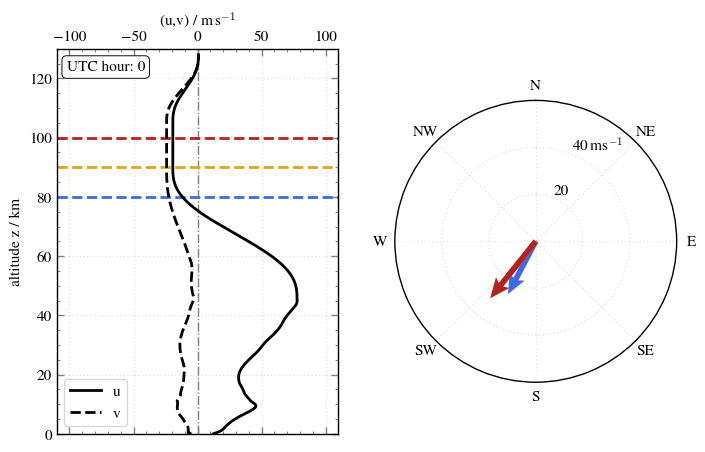

In [35]:
"""Pad wind profiles at upper boundary"""
icut = 113
npad = 207
icutv = 150
npadv = 170
vres = ds['level'].values[1]-ds['level'].values[0]
u  = np.concatenate((dsm['u'].values[:icut+1], dsm['u'].values[icut] * np.ones(npad)))
v  = np.concatenate((dsm['v'].values[:icutv+1], dsm['v'].values[icutv] * np.ones(npadv)))

levels = np.arange(0, len(v)*vres, vres)
levels_pad= levels[-npad:]
print("Array legth: ", len(levels), "Max Alt: ", levels[-1])


def tide_range(levels, zt0, zt1, zt2):
    r1 = np.where((levels>zt0) & (levels<=zt1), tf((levels-zt0)/(zt1-zt0)), 0)
    r2 = np.where((levels>zt1) & (levels<=zt2), 1-tf((levels-zt1)/(zt2-zt1)), 0)
    r3 = r1 + r2
    return r3

"""Base wind profile"""
zcut0 = levels[icut]
zcut1 = 90.e3
zcut2 = 105.e3
u00 = 97 # depends on PNJ maximum
u01 = 20
r00 = np.where((levels>zcut0), tf((levels-zcut0)/(zcut1-zcut0)), 0)
r00 = np.where(levels>zcut1, 1, r00)
r01 = np.where((levels>zcut2), tf((levels-zcut2)/(np.max(levels)-zcut2)), 0)
u = u-u00*r00 + u01*r01
u = scipy.ndimage.gaussian_filter(u, 1, axes=0) 

v00 = 22
v01 = 25
v = v-v00*r00 + v01*r01

"""Tide layers"""
# u_amp_0 = 30
# zt00=55.e3 
# zt01=75.e3
# zt02=85.e3
# r0 = tide_range(levels,zt00, zt01, zt02)

uamp1 = 45
zt10=45.e3 
zt11=75.e3
zt12=105.e3

uamp2 = 70
zt20=70.e3 
zt21=105.e3
zt22=np.max(levels)

uamp3 = 45
zt30=50.e3 
zt31=80.e3
zt32=100.e3

uamp4 = 55
zt40=80.e3 
zt41=100.e3
zt42=zt22

r1u = tide_range(levels,zt10, zt11, zt12)
r2u = tide_range(levels,zt20, zt21, zt22)
r3u = tide_range(levels,zt10, zt11, zt12)
r4u = tide_range(levels,zt20, zt21, zt22)


"""Temporal component of tide u(t,z)"""
def ftide(zetai, phase=0, nlayers=321):
    pi = np.pi
    zetai = zetai - phase
    zetai = np.where(zetai>0, zetai, 0)
    # ftide = np.abs(np.sin(pi*zetai))
    ftide = np.sin(pi*zetai)**2
    # ftide0 = np.cos(pi*zetai0-pi/2)**2
    return np.tile(ftide, (nlayers,1)).T

Ttide = 12*3600
zetai = np.linspace(0,2*Ttide,24) / Ttide
zetai = np.linspace(0,3*Ttide,48) / Ttide

# - Phase shift in fraction of period - #
# phase0 = 0.5
# ftide_u0 = ftide(zetai, phase=phase0)

ftide_u1 = ftide(zetai, phase=0.3)
ftide_v1 = ftide(zetai, phase=0.55)

ftide_u2 = ftide(zetai, phase=0)
ftide_v2 = ftide(zetai, phase=0.25)

ut = u + ftide_u2*uamp2*r2u + ftide_u1*uamp1*r1u # + ftide_u0*u_amp_0*r0
vt = v + ftide_v2*uamp4*r4u + ftide_v1*uamp3*r3u

"""Define phase 0 and phase 1"""
uphase0 = u + uamp2*r2u # Add upper layer for phase 0
uphase1 = u + uamp1*r1u 

folder   = "../data/eulag/figures/2D-tide"
plot_tide_timestamp(0, u, v, levels, folder)

In [11]:
%%capture
folder   = "../data/eulag/figures/2D-tide"
for t in range(np.shape(ut)[0]):
    plot_tide_timestamp(t, ut[t,:], vt[t,:], levels, folder)
plt_helper.create_animation(folder,os.path.join(folder,"2D-tide.mp4"),fps=6)
# plot_tide_timestamp(0, ut[0,:], levels, folder)

In [14]:
"""Pad other profiles at upper boundary"""
icut = 170
npad = 150
levels_pad= levels[-npad:]
print("Array legth: ", len(levels), "Max Alt: ", levels[-1])

th_slc = slice(150,170)
# coefficients_th = np.polyfit(dsm['level'].values[th_slc], dsm['th'].values[th_slc], 2)
coefficients_th = np.polyfit(dsm['level'].values[th_slc], np.log(dsm['th'].values[th_slc]), 1)
th_pad = np.polyval(coefficients_th, levels_pad)
th = np.concatenate((dsm['th'].values[:icut+1], np.exp(th_pad)))
N  = (g/th * np.gradient(th, vres))**(1/2)

rho_slc = slice(150,170)
# coefficients_rho = np.polyfit(ds['level'].values[rho_slc], dsm['rho'].values[rho_slc], 2)
coefficients_rho = np.polyfit(ds['level'].values[rho_slc], np.log(dsm['rho'].values[rho_slc]), 1)
rho_pad = np.polyval(coefficients_rho, levels_pad)
rho = np.concatenate((dsm['rho'].values[:icut+1], np.exp(rho_pad)))

temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd)) #+ 273.15 # 

Array legth:  321 Max Alt:  128000.0


/tmp/ipykernel_25569/2639142090.py:96: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


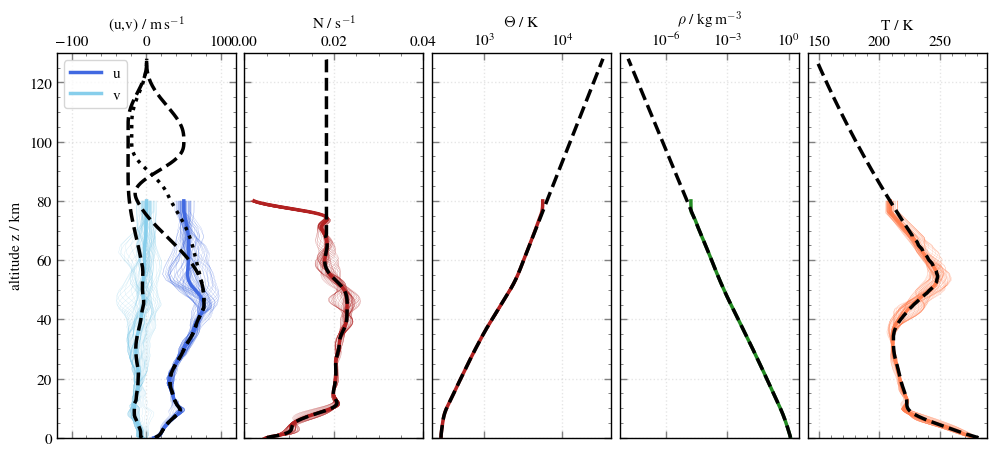

In [15]:
"""Vis env"""
# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
fig, axes = plt.subplots(1,5, figsize=(12,5),sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.05})
ax_wind  = axes[0]
ax_n     = axes[1]
ax_th    = axes[2]
ax_rho   = axes[3]
ax_t     = axes[4]

# ax.set_aspect("equal", adjustable='datalim')
"""Wind"""
lws = 0.1
lwl = 2.5
for t in range(len(ds.time)):
    ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color="royalblue")
    ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color="skyblue")
ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="u")
ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="v")
ax_wind.plot(uphase0, levels/1000, lw=lwl, ls='--', color="black")
ax_wind.plot(uphase1, levels/1000, lw=lwl, ls='dotted', color="black")
ax_wind.plot(v, levels/1000, lw=lwl, ls='--', color="black")
ax_wind.legend(loc="upper left")

ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
ax_wind.set_ylabel("altitude z / km")
ax_wind.set_xlim([-120,120])
ax_wind.set_ylim([0,130])
ax_wind.xaxis.set_label_position('top')
ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_wind.grid()


"""N"""
for t in range(len(ds.time)):
    ax_n.plot(ds["N"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_n.plot(dsm["N"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_n.plot(N, levels/1000, lw=lwl, ls='--', color="black")
ax_n.set_xlabel("N / s$^{-1}$")
ax_n.set_xlim([0,0.04])

ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_minor_locator(AutoMinorLocator())
ax_n.yaxis.set_minor_locator(AutoMinorLocator())
ax_n.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_n.grid()

"""Theta"""
for t in range(len(ds.time)):
    ax_th.plot(ds["th"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_th.plot(dsm["th"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_th.plot(th, levels/1000, lw=lwl, ls='--', color="black")
ax_th.set_xlabel("$\Theta$ / K")
# ax_th.set_xticks([2500,5000,7500])
ax_th.set_xscale('log')


ax_th.xaxis.set_label_position('top')
ax_th.xaxis.set_minor_locator(AutoMinorLocator())
ax_th.yaxis.set_minor_locator(AutoMinorLocator())
ax_th.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_th.grid()

"""Rho"""
for t in range(len(ds.time)):
    ax_rho.plot(ds["rho"][t], ds["level"]/1000, lw=lws, color="forestgreen")
ax_rho.plot(dsm["rho"], dsm["level"]/1000, lw=lwl, color="forestgreen")
ax_rho.plot(rho, levels/1000, lw=lwl, ls='--', color="black")
ax_rho.set_xlabel("$\\rho$ / kg$\,$m$^{-3}$")
ax_rho.set_xscale('log')

ax_rho.xaxis.set_label_position('top')
ax_rho.xaxis.set_minor_locator(AutoMinorLocator())
ax_rho.yaxis.set_minor_locator(AutoMinorLocator())
ax_rho.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_rho.grid()

"""T"""
for t in range(len(ds.time)):
    ax_t.plot(ds["t"][t], ds["level"]/1000, lw=lws, color="coral")
ax_t.plot(dsm["t"], dsm["level"]/1000, lw=lwl, color="coral")
ax_t.plot(temp, levels/1000, lw=lwl, ls='--', color="black")

ax_t.set_xlabel("T / K")

ax_t.xaxis.set_label_position('top')
ax_t.xaxis.set_minor_locator(AutoMinorLocator())
ax_t.yaxis.set_minor_locator(AutoMinorLocator())
ax_t.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_t.grid()

"""Save figure"""
folder   = "../data/eulag/figures"
fig_name = "env.png"
fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [16]:
"""Create NETCDF"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("../data/eulag/env", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

In [6]:
%%capture
"""SAAMER winds actual measurements with ERA5"""
saamer_file_path = "/export/data/SAAMER/SAAMER_Hindley22_version_2018.nc"

ds_saamer = xr.open_dataset(saamer_file_path)
base_date = datetime.datetime(2018,1,1,0,0)
datetime_index = [base_date + datetime.timedelta(days=int(ts), minutes=(ts-int(ts))*24*60) for ts in ds_saamer['time'].values]
ds_saamer = ds_saamer.assign_coords(time=datetime_index)

# - Actual period - #
time_slc  = slice(datetime.datetime(2018,6,16,0,0), datetime.datetime(2018,6,18,23,0))
ds_saamer = ds_saamer.sel(time=time_slc)

for time in ds_saamer.time:
    fig, ax_wind = plt.subplots(1,1, figsize=(4,5))

    # ax.set_aspect("equal", adjustable='datalim')
    """Wind"""
    lws = 0.1
    lwl = 2.5
    # for t in range(len(ds.time)):
    #     ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color="royalblue")
    #     ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color="skyblue")
    ax_wind.plot(ds["u"].sel(time=time), ds["level"]/1000, lw=lwl, color="royalblue", label="ERA5 u")
    ax_wind.plot(ds["v"].sel(time=time), ds["level"]/1000, lw=lwl, color="skyblue", label="ERA5 v")
    ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, ls='--', color="royalblue")
    ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, ls='--', color="skyblue")

    ax_wind.plot(ds_saamer["zonal_wind"].sel(time=time), ds_saamer["altitude"], lw=lwl, color="darkslateblue", label="SAAMER u")
    ax_wind.plot(ds_saamer["meridional_wind"].sel(time=time), ds_saamer["altitude"], lw=lwl, color="violet", label="SAAMER v")
    ax_wind.legend(loc="lower left")

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-110,110])
    ax_wind.set_ylim([0,120])
    ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
    ax_wind.grid()

    ax_wind.text(0.035, 0.97, f"UTC: {datetime.datetime.strftime(pd.to_datetime(time.values),format='%Y-%m-%d %H:%M')}", transform=ax_wind.transAxes, verticalalignment='top', horizontalalignment='left', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})


    """Save figure"""
    folder   = "../data/eulag/figures/saamer_20180616"
    os.makedirs(folder, exist_ok=True)

    fig_name = 'saamer_' + datetime.datetime.strftime(pd.to_datetime(time.values),format='%Y-%m-%dH%H:%M') + '.png'
    fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') 

In [7]:
folder   = "../data/eulag/figures/saamer_20180616"
plt_helper.create_animation(folder,os.path.join(folder,"saamer_20180616.mp4"),fps=6)

In [65]:
%%capture
"""SAAMER winds hourly grouping for winter season"""
saamer_file_path = "/export/data/SAAMER/SAAMER_Hindley22_version_2018.nc"

ds_saamer = xr.open_dataset(saamer_file_path)
base_date = datetime.datetime(2018,1,1,0,0)
datetime_index = [base_date + datetime.timedelta(days=int(ts), minutes=(ts-int(ts))*24*60) for ts in ds_saamer['time'].values]
ds_saamer = ds_saamer.assign_coords(time=datetime_index)

# - Average July conditions - # 
time_slc  = slice(datetime.datetime(2018,5,1,0,0), datetime.datetime(2018,6,1,0,0))
ds_saamer = ds_saamer.sel(time=time_slc)
ds_saamer_h = ds_saamer.groupby('time.hour').mean()
ds_saamer_h

def plot_saamer_timestamp(hour, ds_saamer_h: object, dsm: object, ds: object):
    fig, (ax_wind, ax_rose) = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [4, 5]})

    """Wind profile plot"""
    lws = 0.1
    lwl = 2.5
    for t in range(len(ds.time)):
        ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color="royalblue")
        ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color="skyblue")
    ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="ERA5 u")
    ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="ERA5 v")

    ax_wind.plot(ds_saamer_h["zonal_wind"][hour], ds_saamer_h["altitude"], lw=lwl, color="darkslateblue", label="SAAMER u")
    ax_wind.plot(ds_saamer_h["meridional_wind"][hour], ds_saamer_h["altitude"], lw=lwl, color="violet", label="SAAMER v")
    ax_wind.legend(loc="lower left")

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-110, 110])
    ax_wind.set_ylim([0, 120])
    ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=False, labeltop=True, color="grey")
    ax_wind.grid()

    ax_wind.text(0.035, 0.97, f"UTC hour: {hour}", transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

    """Wind rose plot"""
    ax_rose.remove()
    ax_rose = fig.add_subplot(1, 2, 2, projection='polar')

    altitudes = [80, 90, 100]  # Altitudes at which to plot wind vectors
    u_wind = ds_saamer_h["zonal_wind"][hour].sel(altitude=altitudes)
    v_wind = ds_saamer_h["meridional_wind"][hour].sel(altitude=altitudes)

    r = np.sqrt(u_wind**2 + v_wind**2)  # Wind speed (magnitude)
    theta = (90 - np.degrees(np.arctan2(v_wind, u_wind))) % 360
    
    ax_rose.set_theta_zero_location('N')  # Set 0° to point north
    ax_rose.set_theta_direction(-1) 
    
    cols = ["firebrick", "royalblue", "goldenrod"]
    for i in range(0,len(altitudes)):
        ax_rose.quiver(0,0, theta[i]*np.pi/180, r[i], angles='xy',
                       scale=1, scale_units='xy', width=0.02, headwidth=3, headlength=3.5, headaxislength=3, color=cols[i])
        ax_wind.axhline(altitudes[i], ls="--", lw=2, color=cols[i])

        # print("col: ", cols[i])
        # print("u: ", u_wind[i].values)
        # print("v: ", v_wind[i].values)
        # print("Theta: ", theta[i].values)
        # print("R: ", r[i].values)

    ax_rose.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax_rose.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']) 
    ax_rose.set_rlim(0, 60)
    ax_rose.set_rticks([20,40],labels=[20,"40$\,$ms$^{-1}$"])  # Hide the radial ticks
    ax_rose.grid(True)        

    """Save figure"""
    folder = "../data/eulag/figures/saamer_JJA"
    os.makedirs(folder, exist_ok=True)

    fig_name = 'saamer_' + '{:02d}'.format(hour) + '.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')


for hour in ds_saamer_h.hour:
    plot_saamer_timestamp(hour.values, ds_saamer_h, dsm, ds)
# hour=23
# plot_saamer_timestamp(hour, ds_saamer_h, dsm, ds)

In [66]:
# import shutil
# shutil.rmtree(folder)
folder = "../data/eulag/figures/saamer_JJA"
plt_helper.create_animation(folder,os.path.join(folder,"saamer_May.mp4"), fps=5)

In [ ]:
# saamer_file_path_old = "/export/data/SAAMER/SAAMER_Hindley22_version_2018_old.nc"
# saamer_file_path     = "/export/data/SAAMER/SAAMER_Hindley22_version_2018.nc"

# ds_saamer = xr.open_dataset(saamer_file_path_old)
# ds_saamer["zonal_wind"].values = ds_saamer["zonal_wind"].values[::-1,:]
# ds_saamer["meridional_wind"].values = ds_saamer["meridional_wind"].values[::-1,:]
# ds_saamer.to_netcdf(saamer_file_path)

In [ ]:
"""Add tide implemented in EULAG to wind profiles"""
u_amp_0 = 60
zt0=55.e3 
zt1=90.e3
zt2=110.e3

pi = np.pi

r2 = np.where((levels>zt0) & (levels<=zt1), tf((levels-zt0)/(zt1-zt0)), 0)
r3 = np.where((levels>zt1) & (levels<=zt2), 1-tf((levels-zt1)/(zt2-zt1)), 0)
r4 = r2+r3

Ttide = 12*3600
zetai = np.linspace(0,24*3600,24) / Ttide
ftide_u = np.cos(pi*zetai-pi/2)**2.

ftide_u = np.tile(ftide_u, (301,1)).T

# - Animation - #
ut = u + u_amp_0 * ftide_u * r4

# - Create positive phase profiles!!! - #
umax = u + u_amp_0 * r4
# u = umax

In [ ]:
# """Tide layers"""
# u_amp_0 = 30
# zt00=60.e3 
# zt01=75.e3
# zt02=90.e3
# r0 = tide_range(levels,zt00, zt01, zt02)

# u_amp_1 = 60
# zt10=70.e3 
# zt11=85.e3
# zt12=100.e3
# r1 = tide_range(levels,zt10, zt11, zt12)

# u_amp_2 = 90
# zt20=80.e3 
# zt21=95.e3
# zt22=110.e3
# r2 = tide_range(levels,zt20, zt21, zt22)